## Analyse network data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from lib.const import *

In [2]:
# change it to select another attack dataset
attack_index = 1

In [3]:
if not os.path.exists(f'{CLEANED_DATA_DIR}/Network datatset'):
    os.makedirs(f'{CLEANED_DATA_DIR}/Network datatset')

In [4]:
# Open attack.cs
df_attack = pd.read_csv(f'{DATA_DIR}/Network datatset/csv/attack_{attack_index}.csv', delimiter=',', header=0)
# 5527409 rows attack_1
# 5159469 rows attack_2
# 5862547 rows attack_3
# 5522490 rows attack_4

In [5]:
df_attack = df_attack.drop_duplicates()

In [6]:
print(df_attack.shape)
print(df_attack.columns)

(5527407, 16)
Index(['Time', ' mac_s', ' mac_d', ' ip_s', ' ip_d', ' sport', ' dport',
       ' proto', ' flags', ' size', ' modbus_fn', ' n_pkt_src', ' n_pkt_dst',
       ' modbus_response', ' label_n', ' label'],
      dtype='object')


In [7]:
# Change the name of the columns by removing the spaces
df_attack.columns = df_attack.columns.str.replace(' ', '')

In [8]:
print("Number of rows before droping: ", len(df_attack))
column_NaN = ['Time','mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'proto', 'size', 'n_pkt_src', 'n_pkt_dst', 'label']
df_attack = df_attack.dropna(subset=column_NaN)
print("Number of rows after droping: ", len(df_attack))

Number of rows before droping:  5527407
Number of rows after droping:  5526894


In [9]:
def get_columns_info(column_name):
    print('Column name: ', column_name)
    print('Number of unique values in attack: ', df_attack[column_name].nunique())
    print('Number of missing values in attack: ', df_attack[column_name].isnull().sum())
    print('Number of values in attack: ', df_attack[column_name].count())
    print('Values in attack: ', df_attack[column_name].unique())
    print('Values count: ', df_attack[column_name].value_counts())

# Début Rapport d'analyse

problème avec ces colonne : 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst', 'modbus_fn', 'modbus_response'
raison : missing some values

problème avec modbus_fn, lot of missing value (153121 for attack1), useless column ? Même chose avec modbus_response : Colonne lié au proto modbus et donc pas toute les colonne

La colonne proto contient les protocoles ARP ICMP Modbus TCP pour attack mais seulement Modbus et TCP pour le cas normal

Problème de typage : 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst'

Certaine dates sont partagé pour plusieurs entrées (ex : 2021-04-09 18:42:46.997219 a 4 entrés)

Le s dans ip_s, sport est pour source et le d pour destination

Il y a des cas noté normaux dans les csv attack, besoin du csv normal ?

different types d'attaques : 

 - ['normal' 'anomaly' 'MITM' 'physical fault'] pour attack_1
 - ['normal' 'physical fault' 'anomaly' 'DoS' 'MITM'] pour attack_3
 - ['normal' 'scan' 'DoS' 'physical fault' 'MITM'] pour attack_4 et attack_2


In [10]:
get_columns_info('label_n')
get_columns_info('label')

Column name:  label_n
Number of unique values in attack:  2
Number of missing values in attack:  0
Number of values in attack:  5526894
Values in attack:  [0 1]
Values count:  label_n
0    3687410
1    1839484
Name: count, dtype: int64
Column name:  label
Number of unique values in attack:  3
Number of missing values in attack:  0
Number of values in attack:  5526894
Values in attack:  ['normal' 'MITM' 'physical fault']
Values count:  label
normal            3687410
MITM              1213793
physical fault     625691
Name: count, dtype: int64


In [11]:
# Conversion des types de données
column_type = ['sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst']
for column in column_type:
    df_attack[column] = df_attack[column].astype('int64')

# On retire les brackets [ ] et on convertit en float64, puis on remplace les NaN par -1 et on convertit en int64

df_attack['modbus_response'] = df_attack['modbus_response'].str.replace('[', '', regex=False).str.replace(']', '', regex=False)
df_attack['modbus_response'] = pd.to_numeric(df_attack['modbus_response'], errors='coerce').fillna(-1).astype('int64')

In [12]:
df_attack['Time'] = pd.to_datetime(df_attack['Time'], errors='coerce')

In [13]:
# Conversion en catégories des colonnes proto, flags, label et modbus_fn
df_attack['proto'] = df_attack['proto'].astype('category')
df_attack['flags'] = df_attack['flags'].astype('category')
df_attack['label'] = df_attack['label'].astype('category')
df_attack['modbus_fn'] = df_attack['modbus_fn'].astype('category')

In [14]:
# Save
df_attack.to_csv(f'{CLEANED_DATA_DIR}/Network datatset/attack_{attack_index}_cleaned.csv', index=False)

In [15]:
df_attack.shape

(5526894, 16)

# Test part from here, will be move to a different file

In [16]:
# Analyse exploratoire des données (EDA)
print("Aperçu des données nettoyées :\n", df_attack.head())
print("\nDescription statistique :\n", df_attack.describe(include='all'))

Aperçu des données nettoyées :
                         Time              mac_s              mac_d  \
0 2021-04-09 18:23:28.385003  74:46:a0:bd:a7:1b  0a:fe:ec:47:74:fb   
1 2021-04-09 18:23:28.385005  74:46:a0:bd:a7:1b  e6:3f:ac:c9:a8:8c   
2 2021-04-09 18:23:28.385006  74:46:a0:bd:a7:1b  fa:00:bc:90:d7:fa   
3 2021-04-09 18:23:28.385484  0a:fe:ec:47:74:fb  74:46:a0:bd:a7:1b   
4 2021-04-09 18:23:28.385486  fa:00:bc:90:d7:fa  74:46:a0:bd:a7:1b   

           ip_s          ip_d  sport  dport   proto  flags  size  \
0   84.3.251.20  84.3.251.102  56667    502  Modbus  11000    66   
1   84.3.251.20  84.3.251.101  56666    502  Modbus  11000    66   
2   84.3.251.20  84.3.251.103  56668    502  Modbus  11000    66   
3  84.3.251.102   84.3.251.20    502  56667  Modbus  11000    64   
4  84.3.251.103   84.3.251.20    502  56668  Modbus  11000    64   

             modbus_fn  n_pkt_src  n_pkt_dst  modbus_response  label_n   label  
0   Read Coils Request          0          0             

In [17]:
# KNN algorithm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
# Load the cleaned dataframes

df_attack = pd.read_csv(f'{CLEANED_DATA_DIR}/Network datatset/attack_{attack_index}_cleaned.csv', delimiter=',', header=0)

In [19]:
df_attack.columns

Index(['Time', 'mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'proto',
       'flags', 'size', 'modbus_fn', 'n_pkt_src', 'n_pkt_dst',
       'modbus_response', 'label_n', 'label'],
      dtype='object')

In [20]:
import matplotlib.pyplot as plt

# Subset of normal and attack dataframes
df_label1 = df_attack[df_attack['label_n'] == 1]
df_label0 = df_attack[df_attack['label_n'] == 0]

In [21]:
proto1 = df_label1['proto'].value_counts(normalize=True)
print(proto1)

proto0 = df_label0['proto'].value_counts(normalize=True)
print(proto0)

mac_s1 = df_label1['mac_s'].value_counts(normalize=True)
print(mac_s1)

mac_s0 = df_label0['mac_s'].value_counts(normalize=True)
print(mac_s0)

mac_d1 = df_label1['mac_d'].value_counts(normalize=True)
print(mac_d1)

mac_d0 = df_label0['mac_d'].value_counts(normalize=True)
print(mac_d0)

ip_s1 = df_label1['ip_s'].value_counts(normalize=True)
print(ip_s1)

ip_s0 = df_label0['ip_s'].value_counts(normalize=True)
print(ip_s0)

# Rien de spécial entre attack et normal

proto
Modbus    0.971201
TCP       0.028799
Name: proportion, dtype: float64
proto
Modbus    0.97298
TCP       0.02702
Name: proportion, dtype: float64
mac_s
74:46:a0:bd:a7:1b    0.483955
0a:fe:ec:47:74:fb    0.154007
e6:3f:ac:c9:a8:8c    0.153475
fa:00:bc:90:d7:fa    0.150539
00:80:f4:03:fb:12    0.049846
00:0c:29:47:8c:22    0.002937
fe:bb:16:7b:c3:27    0.002651
4a:35:83:e0:3d:a4    0.002591
Name: proportion, dtype: float64
mac_s
74:46:a0:bd:a7:1b    0.484953
0a:fe:ec:47:74:fb    0.154554
e6:3f:ac:c9:a8:8c    0.154051
fa:00:bc:90:d7:fa    0.150937
00:80:f4:03:fb:12    0.050139
fe:bb:16:7b:c3:27    0.002689
4a:35:83:e0:3d:a4    0.002677
Name: proportion, dtype: float64
mac_d
74:46:a0:bd:a7:1b    0.483949
0a:fe:ec:47:74:fb    0.154893
e6:3f:ac:c9:a8:8c    0.153963
fa:00:bc:90:d7:fa    0.150531
00:80:f4:03:fb:12    0.049845
00:0c:29:47:8c:22    0.002983
fe:bb:16:7b:c3:27    0.001949
4a:35:83:e0:3d:a4    0.001886
Name: proportion, dtype: float64
mac_d
74:46:a0:bd:a7:1b    0.484958
0a:fe

n_pkt_src
15    0.265289
50    0.186703
49    0.081492
51    0.075005
14    0.072367
13    0.036561
4     0.035435
44    0.024502
45    0.023687
18    0.022394
Name: proportion, dtype: float64


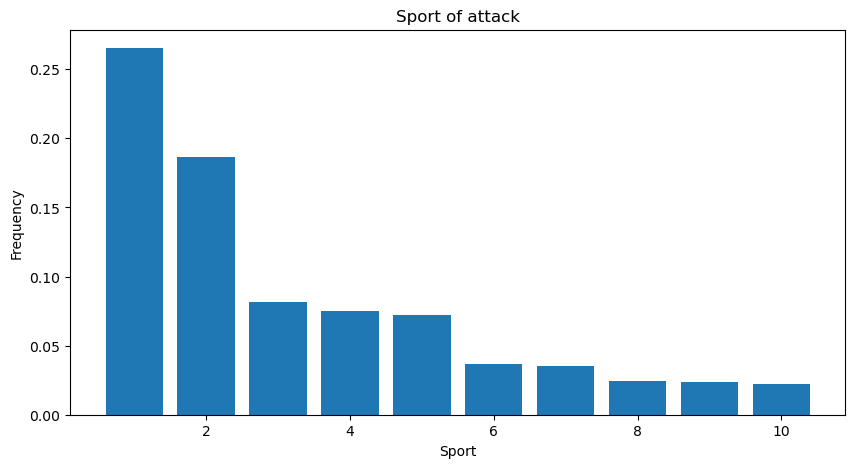

In [22]:
# Plot first 10 sport of attack
sport1 = df_label1['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of attack')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()


n_pkt_src
15    0.278539
50    0.198313
49    0.082377
51    0.080410
14    0.066343
13    0.036580
4     0.035919
44    0.025507
45    0.022964
18    0.021561
Name: proportion, dtype: float64


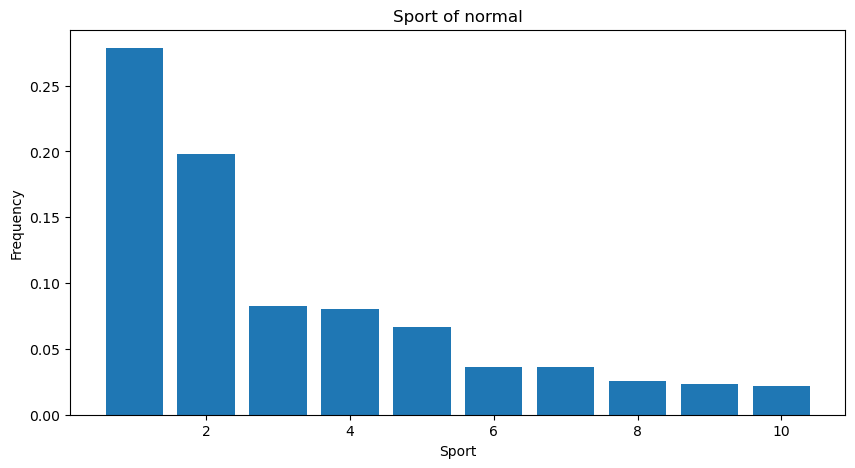

In [23]:
# Plot first 10 sport of attack
sport1 = df_label0['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of normal')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()

In [24]:
# Find the range of Date : '2021-04-19 15:37:19.989214' to '2021-04-19 16:12:14.167723'
df_attack.head(30)

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,n_pkt_src,n_pkt_dst,modbus_response,label_n,label
0,2021-04-09 18:23:28.385003,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,56667,502,Modbus,11000,66,Read Coils Request,0,0,-1,0,normal
1,2021-04-09 18:23:28.385005,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,56666,502,Modbus,11000,66,Read Coils Request,1,0,-1,0,normal
2,2021-04-09 18:23:28.385006,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,56668,502,Modbus,11000,66,Read Coils Request,2,0,-1,0,normal
3,2021-04-09 18:23:28.385484,0a:fe:ec:47:74:fb,74:46:a0:bd:a7:1b,84.3.251.102,84.3.251.20,502,56667,Modbus,11000,64,Read Coils Response,0,0,0,0,normal
4,2021-04-09 18:23:28.385486,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502,56668,Modbus,11000,64,Read Coils Response,0,1,0,0,normal
5,2021-04-09 18:23:28.385500,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502,56666,Modbus,11000,64,Read Coils Response,0,2,0,0,normal
6,2021-04-09 18:23:28.386355,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502,56665,Modbus,11000,64,Read Coils Response,0,3,0,0,normal
7,2021-04-09 18:23:28.387961,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,56667,502,Modbus,11000,66,Read Holding Registers,3,1,-1,0,normal
8,2021-04-09 18:23:28.387964,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,56666,502,Modbus,11000,66,Read Holding Registers,4,1,-1,0,normal
9,2021-04-09 18:23:28.387965,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,56668,502,Modbus,11000,66,Read Holding Registers,5,1,-1,0,normal
